In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/bitcoin_tweets.csv", encoding="latin1")

/var/folders/xk/dxq4c_sd0_v6m2brxq2gyy7r0000gn/T/ipykernel_10135/406433593.py:1: DtypeWarning: Columns (0,5,6,7,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/bitcoin_tweets.csv", encoding="latin1")


In [3]:
df = df[["date", "text", "Polarity Score", "sentiment"]]

In [4]:
df = df.sort_values(by="date")

In [5]:
df = df.dropna()

In [6]:
# Try converting 'date' column to datetime, setting errors='coerce' to turn invalid dates into NaT
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Drop rows where 'date' is NaT (Not a Timestamp)
df = df.dropna(subset=["date"])

In [7]:
# Set 'date' column as index
df = df.set_index("date")

In [8]:
# Sort index if needed
df = df.sort_index()

In [9]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score == 0:
        return "Neutral"
    else:
        return "Negative"
    
# Create a new column called 'Sentiment' 
df["Sentiment"] = df["Polarity Score"].apply(get_sentiment)
df = df.drop(columns=["sentiment"])

In [10]:
df

,text,Polarity Score,Sentiment
date,,,
2021-02-05 10:52:04,2â£ Debunking 9 #Bitcoin Myths by @Patrick_...,0.0,Neutral
2021-02-05 10:52:04,ð Weekend Read ð\n\nKeen to learn about...,0.0,Neutral
2021-02-05 10:52:06,4â£ ðï¸ Bloomberg LP #CryptoOutlook 2021...,0.0,Neutral
2021-02-05 10:52:07,"5â£ #Blockchain 50 2021 by @DelRayMan, @For...",0.0,Neutral
2021-02-05 10:52:26,#reddcoin #rdd @reddcoin to the moon #altcoin ...,0.0,Neutral
...,...,...,...
2021-08-21 12:58:20,@PeterMcCormack Does like censor the truth. #B...,0.0,Neutral
2021-08-21 12:58:21,"If #VET breaks out, it breaks out like a bull!...",0.0,Neutral
2021-08-21 12:58:27,- #Bitcoin just cant stop going up ð\n- We'...,0.0,Neutral


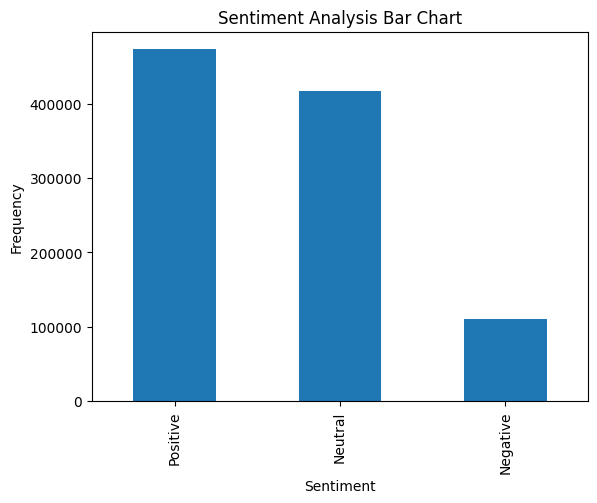

In [11]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Analysis Bar Chart')
plt.xlabel('Sentiment')
plt.ylabel('Frequency');

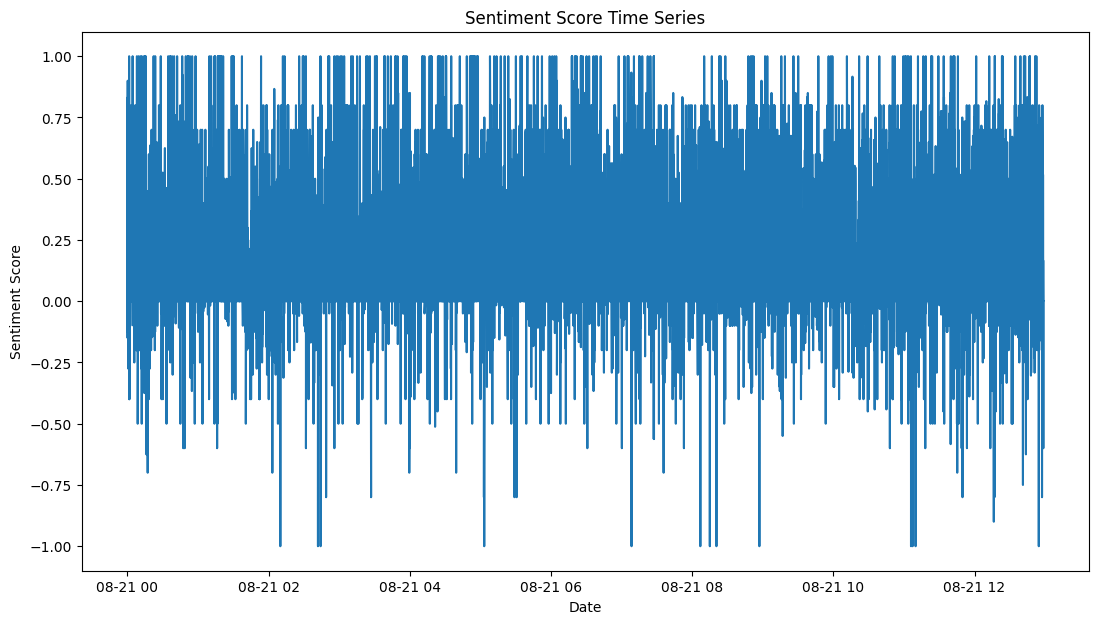

In [12]:
# Filter data for dates after 2021-08-01
df_filtered = df[df.index >= '2021-08-21']

# Plot sentiment scores
plt.figure(figsize=(13, 7))
plt.plot(df_filtered.index, df_filtered['Polarity Score'])
plt.title('Sentiment Score Time Series')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.show()